# Hidden Markov Models (forcasting weather)

## Importing and Cleaning the data 

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('seattle.csv',)

# Cleaning the data 

# Removing empty cells as this is weather data
data = data.dropna()

# Cleaning  wrong date formats  
data['date'] = pd.to_datetime(data['date'],format= 'mixed')

# Handel missing non positive values in Temp
Temp = data['temp_max']
Temp = Temp.dropna()
Temp = Temp[Temp > 0]

print(len(data['temp_max']))

1461


## P-P and ADF test for stationarity(For Tempreture)

In [86]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(Temp)

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -2.6081370616799884
p-value: 0.09132713748034932
Critical Values:
   1%: -3.4348835326305642
   5%: -2.863542248636555
   10%: -2.5678359819686065


#### Test Result
- The adf test reveals that that the data is not stationary at the given confidance interval therfore a transformation is required
- Remove the seasonality component given the context of weather data.
- Using a rolling mean of 30 days  $$ T' = T - 1/30 * \sum_{i=1}^n (T_{t-i}) $$ 
- As a result lost the first 30 data point
- Question to look into , what happens when there arent 30 datapoint to caluculate a mean then adjust from?

In [87]:
import numpy as np

TempTransformed = (data['temp_max']-data['temp_max'].rolling(30).mean())*1461 #<- Number of elem
TempTransformed = TempTransformed.dropna() #<- Failed first time as the roling meand gave NaN for the first 30 data points

# Retesting for Stationarity 

result2 = adfuller(TempTransformed)

print("ADF Statistic:", result2[0])
print("p-value:", result2[1])
print("Critical Values:")
for key, value in result2[4].items():
    print(f"   {key}: {value}")

ADF Statistic: -7.794189306474672
p-value: 7.796691031254991e-12
Critical Values:
   1%: -3.4349569928153607
   5%: -2.863574667579351
   10%: -2.5678532457009697


#### Test Two Results 
- The data is Stationary significat to 1%> , furthermore for the pupose variation applying a first diffrance transformation.
- The trasnformation has form $$ x _t =  \delta T _t = T_t - T_{t-1} $$

In [88]:
TempTransformed2 = (TempTransformed).diff()
TempTransformed2 = TempTransformed2.dropna()
# Retesing for  Stationarity

result3 = adfuller(TempTransformed2)

print("ADF Statistic:", result3[0])
print("p-value:", result3[1])
print("Critical Values:")
for key, value in result3[4].items():
    print(f"   {key}: {value}")


ADF Statistic: -12.096997791742943
p-value: 2.0595944887715698e-22
Critical Values:
   1%: -3.434999576596685
   5%: -2.8635934599975106
   10%: -2.5678632530961614


#### Further improvements on stationarity , no further transformation(except maybe stadardisation as a result of the model being a HMM) reqired.

In [89]:
### 

## Training a Makov Chain (side project)
- Implementing a transioin prob matrix from scratch using the weather col as the state apace and calulation each transision prob from that.

In [90]:
# Trying to find the differnt possible states and define the statespace

types = set(data['weather'])
print(types)

{'snow', 'rain', 'drizzle', 'fog', 'sun'}


In [91]:
Weather = data['weather'] #<- The State Space is as follows {'snow', 'rain', 'drizzle', 'fog', 'sun'}
types = set(data['weather']) 

# Creating a func to make the intial transition  matrix with null values.
def CreateTransMatrix(df):
    dim = len(set(data['weather']))
    TransMatrix = np.zeros((dim,dim), dtype=float)
    return TransMatrix


# Building a function to get the probability oof each entry in the transtion prob. matrix 
def GetCellProb(df,State_1,State_2):
    # State 1 is the state x_t and State two is x_t+1 > Through the markov property
    # Plan: Go through the entire array(Temp) then if at i its state_1 and at i+1 its state_2 then add to a counter 
    Counter_trans = 0  # <- Number of desierd trans.
    Counter = 0 # <- Number of total trans.  
    for i in range(len(df)-1):
        if df[i] == State_1:
            if df[i+1] == State_2:
                Counter_trans += 1
                Counter += 1
            else:
                Counter += 1

    return (Counter_trans/Counter) if Counter > 0 else 0 #<- incase there are no trans.


# Test 
# print(GetCellProb(Weather,'snow','rain'))
# print(CreateTransMatrix(Weather))
# From the test i get the probalility from doing from snow to rain given the data that the model is provided with and to what the result od CreateTransMatrix is 

def GetTransitionProb(array):
    
    types = sorted(set(array))
    Matrix = CreateTransMatrix(array)

    for i in range(len(types)):
        for n in range(len(types)):
            Matrix[i,n] = GetCellProb(array,types[i],types[n])
    return Matrix

# Test
print(GetTransitionProb(Weather))


[[0.30188679 0.05660377 0.35849057 0.         0.28301887]
 [0.00990099 0.27722772 0.31683168 0.         0.3960396 ]
 [0.02808112 0.05616225 0.67394696 0.01716069 0.22464899]
 [0.03846154 0.         0.38461538 0.38461538 0.19230769]
 [0.02503912 0.05320814 0.23161189 0.00782473 0.68231612]]


#### Developed a heat map for asthetic purposes

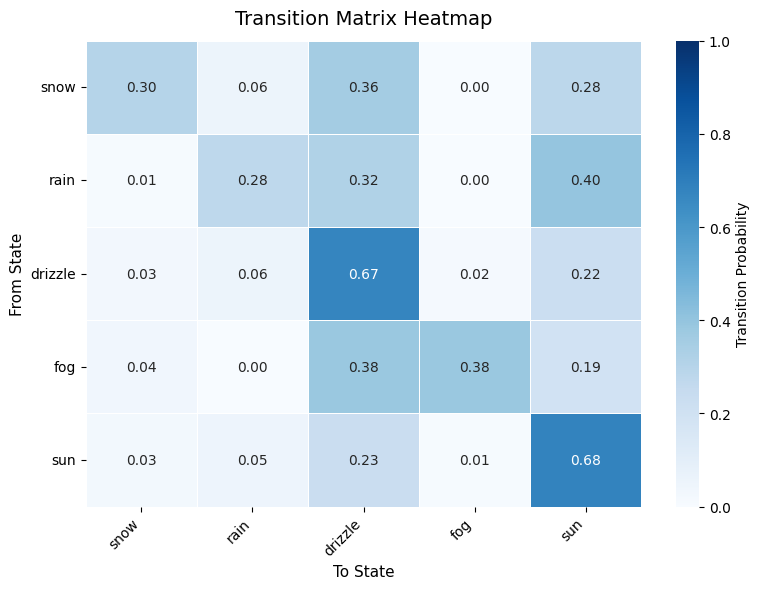

In [95]:
states = ['snow', 'rain', 'drizzle', 'fog', 'sun']
plt.figure(figsize=(8, 6))
matrix = GetTransitionProb(Weather)

sns.heatmap(
    matrix,
    annot=True,           # show values in cells
    fmt=".2f",            # 2 decimal places
    cmap="Blues",         # color scheme
    xticklabels=states,
    yticklabels=states,
    vmin=0, vmax=1,       # fix scale to [0, 1] for probabilities
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Transition Probability"}
)

plt.title("Transition Matrix Heatmap", fontsize=14, pad=12)
plt.xlabel("To State", fontsize=11)
plt.ylabel("From State", fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("transition_heatmap.png", dpi=150)
plt.show()